In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("NBA Young Player Breakout Model")



Matplotlib is building the font cache; this may take a moment.


NBA Young Player Breakout Model


In [3]:
df = pd.read_csv("../data/raw/NBA Player Stats_1998-2025.csv")

df.head()

,Player,Pos,Age,Team,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year
0,A.C. Green,PF,34.0,DAL,82,68,32.3,3.0,6.5,0.453,...,2.7,5.5,8.1,1.5,1.0,0.3,0.8,1.9,7.3,1998
1,Aaron McKie,SG-SF,25.0,PHI,81,32,22.4,1.7,4.7,0.365,...,0.7,2.1,2.9,2.2,1.2,0.2,0.9,2.0,4.1,1998
2,Aaron Williams,PF,26.0,SEA,65,9,11.6,1.8,3.4,0.523,...,0.7,1.5,2.3,0.2,0.3,0.6,0.8,1.8,4.6,1998
3,Adam Keefe,C,27.0,UTA,80,75,25.6,2.9,5.3,0.540,...,2.2,3.2,5.5,1.1,0.7,0.3,0.9,2.2,7.8,1998
4,Adonal Foyle,C,22.0,GSW,55,1,11.9,1.3,3.1,0.406,...,1.3,2.0,3.3,0.3,0.2,0.9,0.9,1.7,3.0,1998


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (13388, 30)

Columns:
['Player', 'Pos', 'Age', 'Team', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Year']


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13388 entries, 0 to 13387
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  13388 non-null  str    
 1   Pos     13388 non-null  str    
 2   Age     13386 non-null  float64
 3   Team    13388 non-null  str    
 4   G       13388 non-null  int64  
 5   GS      13388 non-null  int64  
 6   MP      13388 non-null  float64
 7   FG      13388 non-null  float64
 8   FGA     13388 non-null  float64
 9   FG%     13337 non-null  float64
 10  3P      13388 non-null  float64
 11  3PA     13388 non-null  float64
 12  3P%     11735 non-null  float64
 13  2P      13388 non-null  float64
 14  2PA     13388 non-null  float64
 15  2P%     13292 non-null  float64
 16  eFG%    13337 non-null  float64
 17  FT      13388 non-null  float64
 18  FTA     13388 non-null  float64
 19  FT%     12908 non-null  float64
 20  ORB     13388 non-null  float64
 21  DRB     13388 non-null  float64
 22  TRB     1

In [6]:
df.isnull().sum().sort_values(ascending=False).head(15)

3P%     1653
FT%      480
2P%       96
FG%       51
eFG%      51
PTS        2
Age        2
TOV        0
BLK        0
STL        0
FT         0
PF         0
TRB        0
DRB        0
ORB        0
dtype: int64

In [7]:
df.columns.tolist()

['Player',
 'Pos',
 'Age',
 'Team',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Year']

In [12]:
print(df["Year"].unique())

print(df["Year"].min())
print(df["Year"].max())

df[df["Player"] == "Jayson Tatum"][["Player", "Year", "Age", "Team", "G", "MP", "PTS", "TRB", "AST"]]


[1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
1998
2025


,Player,Year,Age,Team,G,MP,PTS,TRB,AST
9224,Jayson Tatum,2018,19.0,BOS,80,30.5,13.9,5.0,1.6
9766,Jayson Tatum,2019,20.0,BOS,79,31.1,15.7,6.0,2.1
10285,Jayson Tatum,2020,21.0,BOS,66,34.3,23.4,7.0,3.0
10820,Jayson Tatum,2021,22.0,BOS,64,35.8,26.4,7.4,4.3
11385,Jayson Tatum,2022,23.0,BOS,76,35.9,26.9,8.0,4.4
11946,Jayson Tatum,2023,24.0,BOS,74,36.9,30.1,8.8,4.6
12515,Jayson Tatum,2024,25.0,BOS,74,35.7,26.9,8.1,4.9
13082,Jayson Tatum,2025,26.0,BOS,72,36.4,26.8,8.7,6.0


In [13]:
df.groupby(["Player", "Year"]).size().sort_values(ascending=False).head(20)

Player             Year
Tony Battie        2004    2
Marcus Williams    2009    2
Marvin Bagley III  2022    2
Chris Johnson      2013    2
Corey Beck         1999    2
Tony Mitchell      2014    2
Brent Barry        1998    2
A.C. Green         1998    1
Matt Geiger        2000    1
Matt Carroll       2012    1
                   2013    1
Matt Costello      2018    1
Matt Freije        2005    1
                   2007    1
Matt Geiger        1998    1
                   1999    1
                   2001    1
Matt Carroll       2010    1
Matt Geiger        2002    1
Matt Harpring      1999    1
dtype: int64

In [14]:
duplicates = df[
    df.duplicated(subset=["Player", "Year"], keep=False)
].sort_values(["Player", "Year"])

duplicates[["Player", "Year", "Age", "Team", "G", "MP", "PTS", "TRB", "AST"]]

,Player,Year,Age,Team,G,MP,PTS,TRB,AST
50,Brent Barry,1998,26.0,LAC,41,32.7,13.7,3.5,3.2
51,Brent Barry,1998,26.0,MIA,17,15.2,4.1,1.6,1.2
6694,Chris Johnson,2013,22.0,MEM,8,12.8,3.6,1.4,0.3
6695,Chris Johnson,2013,27.0,MIN,30,9.5,3.9,2.0,0.3
528,Corey Beck,1999,27.0,CHH,16,9.4,2.2,1.4,1.3
529,Corey Beck,1999,27.0,DET,8,3.8,1.3,0.6,0.0
5102,Marcus Williams,2009,23.0,GSW,9,6.0,1.3,0.4,1.4
5103,Marcus Williams,2009,22.0,SAS,2,1.5,2.0,0.0,0.0
11509,Marvin Bagley III,2022,22.0,DET,18,27.2,14.6,6.8,1.1
11510,Marvin Bagley III,2022,22.0,SAC,30,21.9,9.3,7.2,0.6


In [15]:
#Create Young Player Dataset
young = df[
    (df["Age"] <= 24) &
    (df["G"] >= 20) &
    (df["MP"] >= 10)
].copy()

print("All player-seasons:", len(df))
print("Eligible young player-seasons:", len(young))

young.head()

All player-seasons: 13388
Eligible young player-seasons: 3556


,Player,Pos,Age,Team,G,GS,MP,FG,FGA,FG%,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Year
4,Adonal Foyle,C,22.0,GSW,55,1,11.9,1.3,3.1,0.406,...,1.3,2.0,3.3,0.3,0.2,0.9,0.9,1.7,3.0,1998
8,Allen Iverson,PG,22.0,PHI,80,80,39.4,8.1,17.6,0.461,...,1.1,2.6,3.7,6.2,2.2,0.3,3.1,2.5,22.0,1998
11,Alvin Williams,SG,23.0,TOR,54,13,19.8,2.3,5.2,0.443,...,0.4,1.1,1.5,1.9,0.7,0.1,1.1,1.5,6.0,1998
12,Andrew DeClercq,C,24.0,BOS,81,49,18.8,2.1,4.2,0.497,...,2.2,2.6,4.8,0.7,1.0,0.6,1.0,3.4,5.4,1998
17,Anthony Johnson,PG,23.0,SAC,77,62,29.4,2.9,7.9,0.371,...,0.7,1.6,2.2,4.3,0.8,0.1,1.6,2.4,7.5,1998


In [16]:
young["Age"].value_counts().sort_index() #Check ages of young players

Age
18.0      3
19.0    133
20.0    328
21.0    509
22.0    733
23.0    888
24.0    962
Name: count, dtype: int64

In [17]:
# Create one row per player per season
clean_df = (
    df.sort_values(["Player", "Year", "G"], ascending=[True, True, False])
      .drop_duplicates(subset=["Player", "Year"], keep="first")
      .copy()
)

print("Original rows:", len(df))
print("Clean rows:", len(clean_df))

Original rows: 13388
Clean rows: 13381


In [18]:
# Statistics we want to compare year-to-year
stats = ["G", "MP", "PTS", "TRB", "AST", "STL", "BLK", "TOV", "FG%", "3P%", "eFG%"]

next_season = clean_df[
    ["Player", "Year"] + stats
].copy()

# Move the year backward so it matches the previous season
next_season["Year"] = next_season["Year"] - 1

# Rename next-season statistics
next_season = next_season.rename(
    columns={stat: f"next_{stat}" for stat in stats}
)

next_season.head()

,Player,Year,next_G,next_MP,next_PTS,next_TRB,next_AST,next_STL,next_BLK,next_TOV,next_FG%,next_3P%,next_eFG%
0,A.C. Green,1997,82,32.3,7.3,8.1,1.5,1.0,0.3,0.8,0.453,0.00,0.453
434,A.C. Green,1998,50,18.5,4.9,4.6,0.5,0.6,0.2,0.4,0.422,0.00,0.422
867,A.C. Green,1999,82,23.5,5.0,5.9,1.0,0.6,0.2,0.6,0.447,0.25,0.448
1299,A.C. Green,2000,82,17.2,4.5,3.8,0.5,0.4,0.1,0.5,0.444,0.00,0.444
868,A.J. Bramlett,1999,8,7.6,1.0,2.8,0.0,0.1,0.0,0.4,0.190,NaN,0.190


In [19]:
#Merge current season with following season
model_df = clean_df.merge(
    next_season,
    on=["Player", "Year"],
    how="inner"
)

# Only use players who were young in the CURRENT season
model_df = model_df[
    (model_df["Age"] <= 24) &
    (model_df["G"] >= 20) &
    (model_df["MP"] >= 10)
].copy()

print("Player-season pairs:", len(model_df))

model_df[
    ["Player", "Year", "Age", "PTS", "next_PTS", "MP", "next_MP"]
].head(10)

Player-season pairs: 3154


,Player,Year,Age,PTS,next_PTS,MP,next_MP
4,A.J. Green,2024,24.0,4.5,7.4,11.0,22.7
5,A.J. Guyton,2001,22.0,6.0,5.4,19.1,13.5
6,A.J. Guyton,2002,23.0,5.4,0.0,13.5,4.5
9,A.J. Price,2010,23.0,7.3,6.5,15.4,15.9
10,A.J. Price,2011,24.0,6.5,3.9,15.9,12.9
14,AJ Griffin,2023,19.0,8.9,2.4,19.5,8.6
15,Aaron Brooks,2008,23.0,5.2,11.2,11.9,25.0
16,Aaron Brooks,2009,24.0,11.2,19.6,25.0,35.6
23,Aaron Gordon,2015,19.0,5.2,9.2,17.0,23.9
24,Aaron Gordon,2016,20.0,9.2,12.7,23.9,28.7


In [ ]:
model_df[
    model_df["Player"] == "Jayson Tatum"
][
    ["Player", "Year", "Age", "PTS", "next_PTS", "TRB", "next_TRB",
     "AST", "next_AST", "MP", "next_MP"]
] #Checking against Tatum

,Player,Year,Age,PTS,next_PTS,TRB,next_TRB,AST,next_AST,MP,next_MP
4642,Jayson Tatum,2018,19.0,13.9,15.7,5.0,6.0,1.6,2.1,30.5,31.1
4643,Jayson Tatum,2019,20.0,15.7,23.4,6.0,7.0,2.1,3.0,31.1,34.3
4644,Jayson Tatum,2020,21.0,23.4,26.4,7.0,7.4,3.0,4.3,34.3,35.8
4645,Jayson Tatum,2021,22.0,26.4,26.9,7.4,8.0,4.3,4.4,35.8,35.9
4646,Jayson Tatum,2022,23.0,26.9,30.1,8.0,8.8,4.4,4.6,35.9,36.9
4647,Jayson Tatum,2023,24.0,30.1,26.9,8.8,8.1,4.6,4.9,36.9,35.7


In [21]:
#Year to year changes
# Calculate change from current season to next season

model_df["pts_change"] = model_df["next_PTS"] - model_df["PTS"]
model_df["ast_change"] = model_df["next_AST"] - model_df["AST"]
model_df["trb_change"] = model_df["next_TRB"] - model_df["TRB"]
model_df["mp_change"] = model_df["next_MP"] - model_df["MP"]
model_df["efg_change"] = model_df["next_eFG%"] - model_df["eFG%"]

model_df[
    ["Player", "Year", "PTS", "next_PTS", "pts_change",
     "AST", "next_AST", "ast_change",
     "MP", "next_MP", "mp_change"]
].head(10)

,Player,Year,PTS,next_PTS,pts_change,AST,next_AST,ast_change,MP,next_MP,mp_change
4,A.J. Green,2024,4.5,7.4,2.9,0.5,1.5,1.0,11.0,22.7,11.7
5,A.J. Guyton,2001,6.0,5.4,-0.6,1.9,1.8,-0.1,19.1,13.5,-5.6
6,A.J. Guyton,2002,5.4,0.0,-5.4,1.8,1.0,-0.8,13.5,4.5,-9.0
9,A.J. Price,2010,7.3,6.5,-0.8,1.9,2.2,0.3,15.4,15.9,0.5
10,A.J. Price,2011,6.5,3.9,-2.6,2.2,2.0,-0.2,15.9,12.9,-3.0
14,AJ Griffin,2023,8.9,2.4,-6.5,1.0,0.3,-0.7,19.5,8.6,-10.9
15,Aaron Brooks,2008,5.2,11.2,6.0,1.7,3.0,1.3,11.9,25.0,13.1
16,Aaron Brooks,2009,11.2,19.6,8.4,3.0,5.3,2.3,25.0,35.6,10.6
23,Aaron Gordon,2015,5.2,9.2,4.0,0.7,1.6,0.9,17.0,23.9,6.9
24,Aaron Gordon,2016,9.2,12.7,3.5,1.6,1.9,0.3,23.9,28.7,4.8


In [ ]:
from sklearn.preprocessing import StandardScaler

change_cols = [
    "pts_change",
    "ast_change",
    "trb_change",
    "mp_change",
    "efg_change"
]

# Remove rows missing any of the required outcome statistics
breakout_df = model_df.dropna(subset=change_cols).copy()

scaler = StandardScaler()

scaled_changes = scaler.fit_transform(
    breakout_df[change_cols]
)

scaled_changes[:5]

#Add
breakout_df["breakout_score"] = (
    0.35 * scaled_changes[:, 0] +   # Points
    0.15 * scaled_changes[:, 1] +   # Assists
    0.15 * scaled_changes[:, 2] +   # Rebounds
    0.20 * scaled_changes[:, 3] +   # Minutes
    0.15 * scaled_changes[:, 4]     # eFG%
)

#Table - Head Names
breakout_df[
    [
        "Player", "Year", "Age",
        "PTS", "next_PTS",
        "MP", "next_MP",
        "breakout_score"
    ]
].sort_values(
    "breakout_score",
    ascending=False
).head(20)


,Player,Year,Age,PTS,next_PTS,MP,next_MP,breakout_score
2715,Devonte' Graham,2019,23.0,4.7,18.2,14.7,35.1,3.234091
1322,CJ McCollum,2015,23.0,6.8,20.8,15.7,34.8,2.775601
983,Boris Diaw,2005,22.0,4.8,13.3,18.2,35.5,2.726456
2157,Danny Fortson,2000,23.0,7.6,16.7,15.6,33.8,2.692129
10157,Zach Randolph,2003,21.0,8.4,20.1,16.9,37.9,2.681896
4050,JaKarr Sampson,2018,24.0,4.7,20.0,15.6,31.8,2.672023
4189,Jalen Johnson,2023,21.0,5.6,16.0,14.9,33.7,2.603722
7480,Nikola Vucevic,2012,21.0,5.5,13.1,15.9,33.2,2.422715
775,Baron Davis,2000,20.0,5.9,13.8,18.6,38.9,2.380378
4780,Jermaine O'Neal,2000,21.0,3.9,12.9,12.3,32.6,2.337282


In [25]:
breakout_threshold = breakout_df["breakout_score"].quantile(0.80)

breakout_df["Breakout"] = (
    breakout_df["breakout_score"] >= breakout_threshold
).astype(int)

print("Breakout threshold:", round(breakout_threshold, 3))

print(
    breakout_df["Breakout"]
    .value_counts()
)

Breakout threshold: 0.652
Breakout
0    2520
1     631
Name: count, dtype: int64


In [26]:
#Check big historical breakouts 
top_breakouts = breakout_df[
    [
        "Player", "Year", "Age",
        "PTS", "next_PTS", "pts_change",
        "AST", "next_AST", "ast_change",
        "TRB", "next_TRB", "trb_change",
        "MP", "next_MP", "mp_change",
        "eFG%", "next_eFG%", "efg_change",
        "breakout_score", "Breakout"
    ]
].sort_values("breakout_score", ascending=False)

top_breakouts.head(25)

,Player,Year,Age,PTS,next_PTS,pts_change,AST,next_AST,ast_change,TRB,next_TRB,trb_change,MP,next_MP,mp_change,eFG%,next_eFG%,efg_change,breakout_score,Breakout
2715,Devonte' Graham,2019,23.0,4.7,18.2,13.5,2.6,7.5,4.9,1.4,3.4,2.0,14.7,35.1,20.4,0.421,0.495,0.074,3.234091,1
1322,CJ McCollum,2015,23.0,6.8,20.8,14.0,1.0,4.3,3.3,1.5,3.2,1.7,15.7,34.8,19.1,0.511,0.517,0.006,2.775601,1
983,Boris Diaw,2005,22.0,4.8,13.3,8.5,2.3,6.2,3.9,2.6,6.9,4.3,18.2,35.5,17.3,0.437,0.531,0.094,2.726456,1
2157,Danny Fortson,2000,23.0,7.6,16.7,9.1,0.5,0.8,0.3,6.7,16.3,9.6,15.6,33.8,18.2,0.528,0.580,0.052,2.692129,1
10157,Zach Randolph,2003,21.0,8.4,20.1,11.7,0.5,2.0,1.5,4.5,10.5,6.0,16.9,37.9,21.0,0.513,0.485,-0.028,2.681896,1
4050,JaKarr Sampson,2018,24.0,4.7,20.0,15.3,0.4,1.0,0.6,3.5,8.0,4.5,15.6,31.8,16.2,0.574,0.583,0.009,2.672023,1
4189,Jalen Johnson,2023,21.0,5.6,16.0,10.4,1.2,3.6,2.4,4.0,8.7,4.7,14.9,33.7,18.8,0.537,0.562,0.025,2.603722,1
7480,Nikola Vucevic,2012,21.0,5.5,13.1,7.6,0.6,1.9,1.3,4.8,11.9,7.1,15.9,33.2,17.3,0.455,0.519,0.064,2.422715,1
775,Baron Davis,2000,20.0,5.9,13.8,7.9,3.8,7.3,3.5,2.0,5.0,3.0,18.6,38.9,20.3,0.449,0.472,0.023,2.380378,1
4780,Jermaine O'Neal,2000,21.0,3.9,12.9,9.0,0.3,1.2,0.9,3.3,9.8,6.5,12.3,32.6,20.3,0.486,0.465,-0.021,2.337282,1


In [27]:
#Check Tatum
breakout_df[
    breakout_df["Player"] == "Jayson Tatum"
][
    [
        "Player", "Year", "Age",
        "PTS", "next_PTS",
        "pts_change",
        "MP", "next_MP",
        "efg_change",
        "breakout_score",
        "Breakout"
    ]
]

,Player,Year,Age,PTS,next_PTS,pts_change,MP,next_MP,efg_change,breakout_score,Breakout
4642,Jayson Tatum,2018,19.0,13.9,15.7,1.8,30.5,31.1,-0.032,0.205738,0
4643,Jayson Tatum,2019,20.0,15.7,23.4,7.7,31.1,34.3,0.021,1.116882,1
4644,Jayson Tatum,2020,21.0,23.4,26.4,3.0,34.3,35.8,0.003,0.517006,0
4645,Jayson Tatum,2021,22.0,26.4,26.9,0.5,35.8,35.9,-0.004,0.000500,0
4646,Jayson Tatum,2022,23.0,26.9,30.1,3.2,35.9,36.9,0.017,0.408399,0
4647,Jayson Tatum,2023,24.0,30.1,26.9,-3.2,36.9,35.7,0.009,-0.520168,0


In [28]:
#Future breakout players
comparison = breakout_df.groupby("Breakout")[
    ["Age", "PTS", "AST", "TRB", "MP", "FG%", "3P%", "eFG%"]
].mean().round(2)

comparison

,Age,PTS,AST,TRB,MP,FG%,3P%,eFG%
Breakout,,,,,,,,
0,22.43,10.46,2.15,4.34,24.08,0.46,0.29,0.50
1,21.92,8.19,1.64,3.65,20.24,0.45,0.28,0.49


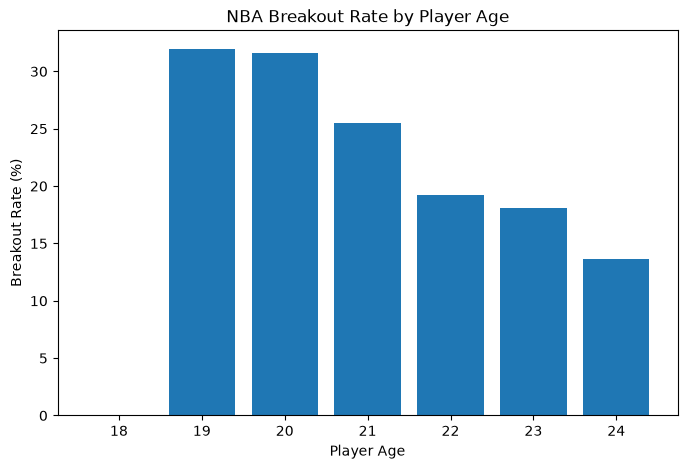

In [ ]:
#Player Breakout Rate by Age
age_breakout = (
    breakout_df.groupby("Age")["Breakout"]
    .mean()
    .reset_index()
)

age_breakout["Breakout_Rate"] = age_breakout["Breakout"] * 100

plt.figure(figsize=(8, 5))

plt.bar(
    age_breakout["Age"],
    age_breakout["Breakout_Rate"]
)

plt.xlabel("Player Age")
plt.ylabel("Breakout Rate (%)")
plt.title("NBA Breakout Rate by Player Age")

plt.show()

<Figure size 800x500 with 0 Axes>

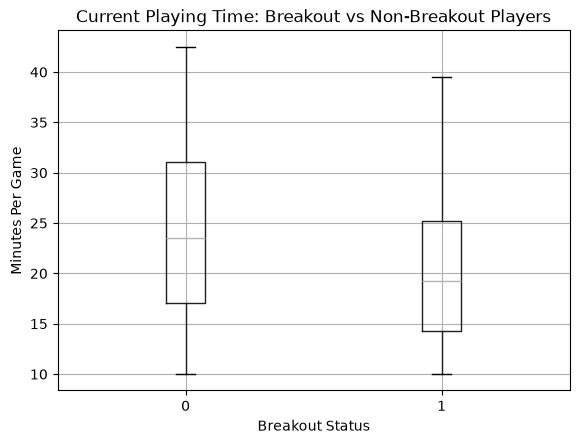

In [ ]:
#Player Breakout Rate by Role (MPG)
plt.figure(figsize=(8, 5))

breakout_df.boxplot(
    column="MP",
    by="Breakout"
)

plt.xlabel("Breakout Status")
plt.ylabel("Minutes Per Game")
plt.title("Current Playing Time: Breakout vs Non-Breakout Players")
plt.suptitle("")

plt.show()

## Predictive Modeling

The goal is to predict whether an eligible young player will experience
a breakout in the following season using only information available
during the current season.

To simulate a realistic forecasting setting, earlier seasons are used
for training and more recent seasons are held out for testing.

In [44]:
features = [
    "Age",
    "G",
    "GS",
    "MP",
    "PTS",
    "TRB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "FG%",
    "3P%",
    "FT%",
    "eFG%"
]

model_data = breakout_df.dropna(
    subset=features + ["Breakout"]
).copy()

print("Observations available:", len(model_data))

Observations available: 2952


In [45]:
#Model Predict Later Seasons
train = model_data[model_data["Year"] <= 2021].copy()
test = model_data[model_data["Year"] >= 2022].copy()

X_train = train[features]
y_train = train["Breakout"]

X_test = test[features]
y_test = test["Breakout"]

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining years:")
print(train["Year"].min(), "-", train["Year"].max())

print("\nTesting years:")
print(test["Year"].min(), "-", test["Year"].max())

#We're pretending we're sitting at the end of 2021 saying: "Based on everything we've 
# learned historically, can we identify breakouts in future seasons?"

Training observations: 2489
Testing observations: 463

Training years:
1998 - 2021

Testing years:
2022 - 2024


In [46]:
#Build LOG Regression 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['Age','G','GS',...,'3P%','FT%','eFG%']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [47]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]
#Make Predictions
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))

print("ROC-AUC:", round(
    roc_auc_score(y_test, y_prob), 3
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.57      0.71       401
           1       0.21      0.73      0.32        62

    accuracy                           0.59       463
   macro avg       0.57      0.65      0.52       463
weighted avg       0.83      0.59      0.66       463

ROC-AUC: 0.688

Confusion Matrix:
[[229 172]
 [ 17  45]]


### Random Forest Model

A Random Forest classifier is evaluated to determine whether nonlinear
relationships and interactions between player characteristics improve
breakout prediction relative to the Logistic Regression baseline.

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 T

In [49]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

#Evaluate 
print(classification_report(y_test, rf_pred))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, rf_prob), 3)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.54      0.68       401
           1       0.20      0.73      0.31        62

    accuracy                           0.57       463
   macro avg       0.56      0.63      0.50       463
weighted avg       0.83      0.57      0.63       463

ROC-AUC: 0.681

Confusion Matrix:
[[217 184]
 [ 17  45]]


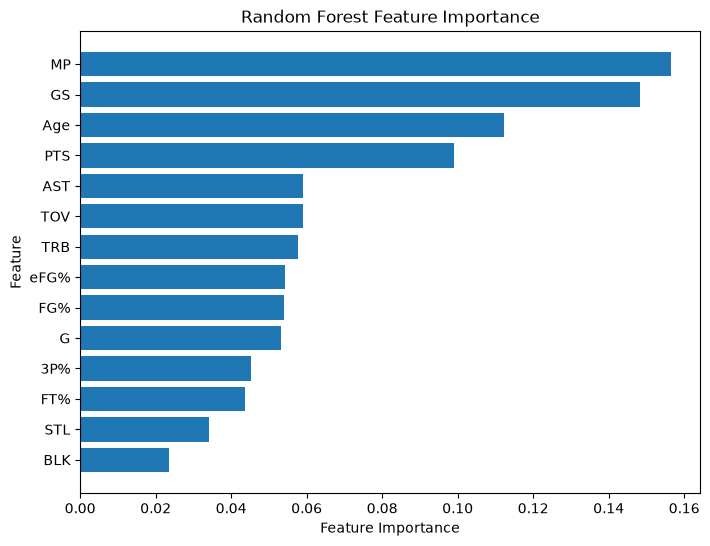

In [50]:
#Random Forest ROC-AUC against your Logistic Regression's 0.688
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance
#Visual
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.show()

So for now, Logistic Regression is our better model. That's actually a nice result to discuss in your project: a more complicated model didn't automatically perform better.

### Why are Players Predicted to Breakout?

In [51]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,MP,0.156409
2,GS,0.148194
0,Age,0.112242
4,PTS,0.099121
6,AST,0.059122
9,TOV,0.059052
5,TRB,0.057831
13,eFG%,0.054365
10,FG%,0.054002
1,G,0.053202


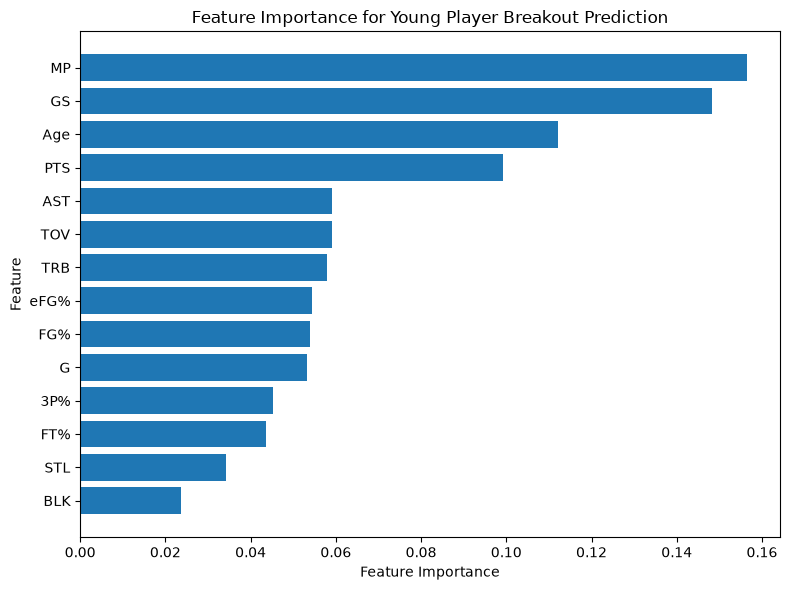

In [52]:
plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Young Player Breakout Prediction")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [53]:
logistic_coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic_model.named_steps["model"].coef_[0]
}).sort_values(
    "Coefficient",
    ascending=False
)

logistic_coefficients

,Feature,Coefficient
1,G,0.235142
7,STL,0.182142
10,FG%,0.123427
12,FT%,0.090533
9,TOV,0.078353
5,TRB,0.077890
11,3P%,0.077064
4,PTS,-0.006412
8,BLK,-0.010841
6,AST,-0.108906


### Player Projectory Model - Improved

In [57]:
#Sort chronologically 
trajectory_df = young.sort_values(
    ["Player", "Year"]
).copy()

#Prev Szn Stats
trajectory_stats = [
    "PTS",
    "AST",
    "TRB",
    "MP",
    "eFG%"
]

for stat in trajectory_stats:
    trajectory_df[f"prev_{stat}"] = (
        trajectory_df.groupby("Player")[stat].shift(1)
    )

#Recent developments
for stat in trajectory_stats:
    trajectory_df[f"{stat}_growth"] = (
        trajectory_df[stat] -
        trajectory_df[f"prev_{stat}"]
    )

#Check Tatum
trajectory_df[
    trajectory_df["Player"] == "Jayson Tatum"
][
    [
        "Player",
        "Year",
        "Age",
        "PTS",
        "prev_PTS",
        "PTS_growth",
        "MP",
        "prev_MP",
        "MP_growth"
    ]
]

,Player,Year,Age,PTS,prev_PTS,PTS_growth,MP,prev_MP,MP_growth
9224,Jayson Tatum,2018,19.0,13.9,NaN,NaN,30.5,NaN,NaN
9766,Jayson Tatum,2019,20.0,15.7,13.9,1.8,31.1,30.5,0.6
10285,Jayson Tatum,2020,21.0,23.4,15.7,7.7,34.3,31.1,3.2
10820,Jayson Tatum,2021,22.0,26.4,23.4,3.0,35.8,34.3,1.5
11385,Jayson Tatum,2022,23.0,26.9,26.4,0.5,35.9,35.8,0.1
11946,Jayson Tatum,2023,24.0,30.1,26.9,3.2,36.9,35.9,1.0


In [60]:
#Merge with Breakout Labels
growth_features = [
    "PTS_growth",
    "AST_growth",
    "TRB_growth",
    "MP_growth",
    "eFG%_growth"
]

trajectory_model_df = breakout_df.merge(
    trajectory_df[
        ["Player", "Year"] + growth_features
    ],
    on=["Player", "Year"],
    how="left"
)

trajectory_model_df[
    [
        "Player",
        "Year",
        "Age",
        "PTS",
        "PTS_growth",
        "MP_growth",
        "Breakout"
    ]
].head(20)

trajectory_model_df.groupby(
    ["Player", "Year"]
).size().sort_values(ascending=False).head(20)

Player                   Year
A.J. Green               2024    1
Melvin Ely               2003    1
Metta World Peace        2001    1
                         2002    1
                         2003    1
                         2004    1
Meyers Leonard           2013    1
                         2015    1
                         2016    1
                         2017    1
Michael Beasley          2009    1
                         2010    1
                         2011    1
                         2012    1
                         2013    1
Michael Bradley          2003    1
Michael Carter-Williams  2014    1
                         2015    1
                         2016    1
Michael Dickerson        1999    1
dtype: int64

In [64]:
#NEW Expanded Feature Set
trajectory_features = [
    "Age",
    "G",
    "GS",
    "MP",
    "PTS",
    "TRB",
    "AST",
    "STL",
    "BLK",
    "TOV",
    "FG%",
    "3P%",
    "FT%",
    "eFG%",
    "PTS_growth",
    "AST_growth",
    "TRB_growth",
    "MP_growth",
    "eFG%_growth"
]

trajectory_data = trajectory_model_df.dropna(
    subset=trajectory_features + ["Breakout"]
).copy()

print("Usable observations:", len(trajectory_data))

#time based splits
trajectory_train = trajectory_data[
    trajectory_data["Year"] <= 2021
].copy()

trajectory_test = trajectory_data[
    trajectory_data["Year"] >= 2022
].copy()

X_train_traj = trajectory_train[trajectory_features]
y_train_traj = trajectory_train["Breakout"]

X_test_traj = trajectory_test[trajectory_features]
y_test_traj = trajectory_test["Breakout"]

print("Training observations:", len(trajectory_train))
print("Testing observations:", len(trajectory_test))

#Train trajectory model
trajectory_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

trajectory_model.fit(X_train_traj, y_train_traj)

#Predict
traj_pred = trajectory_model.predict(X_test_traj)
traj_prob = trajectory_model.predict_proba(
    X_test_traj
)[:, 1]

Usable observations: 1843
Training observations: 1529
Testing observations: 314


In [66]:
#Evalute NEW
print(classification_report(
    y_test_traj,
    traj_pred
))

traj_auc = roc_auc_score(
    y_test_traj,
    traj_prob
)

print("Trajectory Model ROC-AUC:", round(traj_auc, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_test_traj,
    traj_pred
))

              precision    recall  f1-score   support

           0       0.94      0.54      0.68       278
           1       0.17      0.72      0.27        36

    accuracy                           0.56       314
   macro avg       0.55      0.63      0.48       314
weighted avg       0.85      0.56      0.63       314

Trajectory Model ROC-AUC: 0.695

Confusion Matrix:
[[149 129]
 [ 10  26]]


In [67]:
#APPLES TO APPLES EVAL 
baseline_same_data = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

baseline_same_data.fit(
    trajectory_train[features],
    y_train_traj
)

baseline_same_prob = baseline_same_data.predict_proba(
    trajectory_test[features]
)[:, 1]

baseline_same_auc = roc_auc_score(
    y_test_traj,
    baseline_same_prob
)

print("Baseline AUC:", round(baseline_same_auc, 3))
print("Trajectory AUC:", round(traj_auc, 3))
print(
    "Improvement:",
    round(traj_auc - baseline_same_auc, 3)
)

Baseline AUC: 0.678
Trajectory AUC: 0.695
Improvement: 0.016


## Breakout Candidate Rankings

The final model is used to rank young NBA players by their estimated probability of experiencing a breakout in the following season.

In [71]:
latest_year = trajectory_data["Year"].max()

latest_players = trajectory_data[
    trajectory_data["Year"] == latest_year
].copy()

latest_players["Breakout_Probability"] = (
    trajectory_model.predict_proba(
        latest_players[trajectory_features]
    )[:, 1]
)

rankings = latest_players[
    [
        "Player",
        "Age",
        "Team",
        "PTS",
        "TRB",
        "AST",
        "MP",
        "Breakout_Probability"
    ]
].sort_values(
    "Breakout_Probability",
    ascending=False
)

rankings.head(15)

,Player,Age,Team,PTS,TRB,AST,MP,Breakout_Probability
1395,Jaylin Williams,21.0,OKC,4.0,3.4,1.6,13.0,0.851119
2089,Max Christie,20.0,LAL,4.2,2.1,0.9,14.1,0.832483
2331,Ousmane Dieng,20.0,OKC,4.0,1.5,1.1,11.1,0.826083
1218,Jaden Hardy,21.0,DAL,7.3,1.8,1.5,13.5,0.813088
849,Dominick Barlow,20.0,SAS,4.4,3.4,1.1,12.7,0.807165
279,Blake Wesley,20.0,SAS,4.4,1.5,2.7,14.4,0.798219
2924,Trendon Watford,23.0,BRK,6.9,3.1,1.3,13.6,0.784239
903,Dyson Daniels,20.0,NOP,5.8,3.9,2.7,22.3,0.782873
550,Cole Anthony,23.0,ORL,11.6,3.8,2.9,22.4,0.777057
1154,Isaiah Jackson,22.0,IND,6.5,4.0,0.8,13.1,0.765337


In [70]:
print("Latest year:", latest_year)
print("Number of eligible players:", len(latest_players))

Latest year: 2024
Number of eligible players: 100


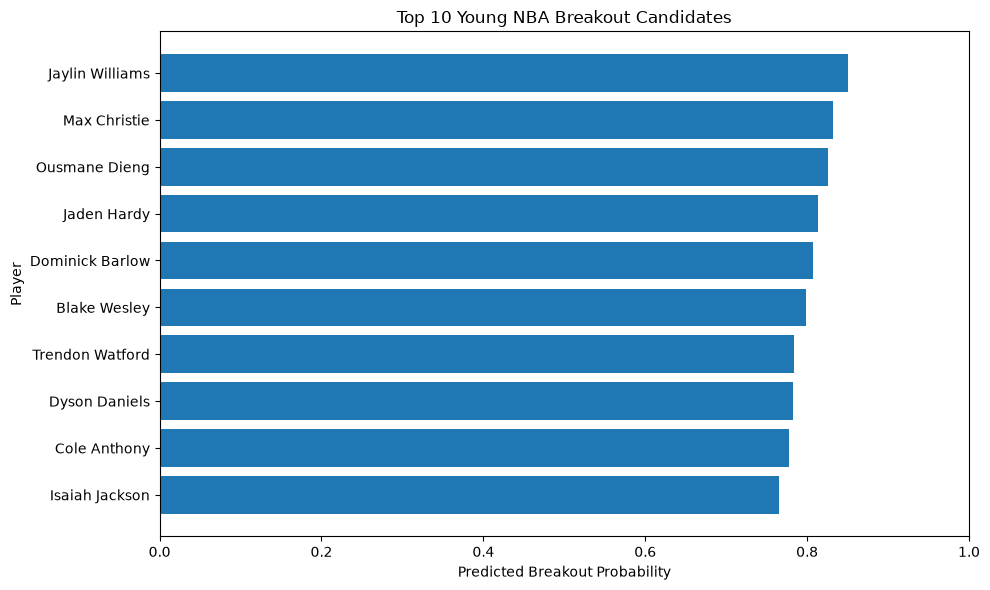

In [75]:
#Final Top 10 Visual
top10 = rankings.head(10).sort_values(
    "Breakout_Probability",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Player"],
    top10["Breakout_Probability"]
)

plt.xlabel("Predicted Breakout Probability")
plt.ylabel("Player")
plt.title("Top 10 Young NBA Breakout Candidates")

plt.xlim(0, 1)

plt.tight_layout()
plt.savefig(
    "../figures/top10_breakout_candidates.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [73]:
# Save player rankings
rankings.to_csv(
    "../data/processed/breakout_rankings.csv",
    index=False
)

# Save full modeling dataset
trajectory_data.to_csv(
    "../data/processed/modeling_dataset.csv",
    index=False
)

print("Files saved successfully!")

Files saved successfully!


## Validation: Did the Predicted Players Actually Break Out?

Because the model generates predictions using 2024 player data, 2025 statistics can be used to evaluate whether the highest-ranked breakout candidates subsequently improved.

In [76]:
# Get 2025 player statistics
actual_2025 = df[df["Year"] == 2025][
    ["Player", "PTS", "TRB", "AST", "MP", "eFG%"]
].copy()

actual_2025 = actual_2025.rename(columns={
    "PTS": "PTS_2025",
    "TRB": "TRB_2025",
    "AST": "AST_2025",
    "MP": "MP_2025",
    "eFG%": "eFG%_2025"
})

# Compare model predictions with actual following-season results
validation = rankings.merge(
    actual_2025,
    on="Player",
    how="left"
)

validation.head(15)

,Player,Age,Team,PTS,TRB,AST,MP,Breakout_Probability,PTS_2025,TRB_2025,AST_2025,MP_2025,eFG%_2025
0,Jaylin Williams,21.0,OKC,4.0,3.4,1.6,13.0,0.851119,5.9,5.6,2.6,16.7,0.577
1,Max Christie,20.0,LAL,4.2,2.1,0.9,14.1,0.832483,9.6,3.3,1.9,27.3,0.525
2,Ousmane Dieng,20.0,OKC,4.0,1.5,1.1,11.1,0.826083,3.8,2.2,0.8,10.9,0.524
3,Jaden Hardy,21.0,DAL,7.3,1.8,1.5,13.5,0.813088,8.7,1.6,1.4,15.9,0.527
4,Dominick Barlow,20.0,SAS,4.4,3.4,1.1,12.7,0.807165,4.2,2.4,0.5,10.7,0.562
5,Blake Wesley,20.0,SAS,4.4,1.5,2.7,14.4,0.798219,3.7,1.1,2.0,11.8,0.481
6,Trendon Watford,23.0,BRK,6.9,3.1,1.3,13.6,0.784239,10.2,3.6,2.6,20.8,0.510
7,Dyson Daniels,20.0,NOP,5.8,3.9,2.7,22.3,0.782873,14.1,5.9,4.4,33.8,0.536
8,Cole Anthony,23.0,ORL,11.6,3.8,2.9,22.4,0.777057,9.4,3.0,2.9,18.4,0.494
9,Isaiah Jackson,22.0,IND,6.5,4.0,0.8,13.1,0.765337,7.0,5.6,1.0,16.8,0.609


In [77]:
validation["PTS_change"] = validation["PTS_2025"] - validation["PTS"]
validation["TRB_change"] = validation["TRB_2025"] - validation["TRB"]
validation["AST_change"] = validation["AST_2025"] - validation["AST"]
validation["MP_change"] = validation["MP_2025"] - validation["MP"]

validation[
    [
        "Player",
        "Breakout_Probability",
        "PTS",
        "PTS_2025",
        "PTS_change",
        "MP",
        "MP_2025",
        "MP_change"
    ]
].head(15)

,Player,Breakout_Probability,PTS,PTS_2025,PTS_change,MP,MP_2025,MP_change
0,Jaylin Williams,0.851119,4.0,5.9,1.9,13.0,16.7,3.7
1,Max Christie,0.832483,4.2,9.6,5.4,14.1,27.3,13.2
2,Ousmane Dieng,0.826083,4.0,3.8,-0.2,11.1,10.9,-0.2
3,Jaden Hardy,0.813088,7.3,8.7,1.4,13.5,15.9,2.4
4,Dominick Barlow,0.807165,4.4,4.2,-0.2,12.7,10.7,-2.0
5,Blake Wesley,0.798219,4.4,3.7,-0.7,14.4,11.8,-2.6
6,Trendon Watford,0.784239,6.9,10.2,3.3,13.6,20.8,7.2
7,Dyson Daniels,0.782873,5.8,14.1,8.3,22.3,33.8,11.5
8,Cole Anthony,0.777057,11.6,9.4,-2.2,22.4,18.4,-4.0
9,Isaiah Jackson,0.765337,6.5,7.0,0.5,13.1,16.8,3.7


In [78]:
# Get the actual breakout outcome for the 2024 prediction cohort
actual_outcomes = trajectory_data[
    trajectory_data["Year"] == latest_year
][
    ["Player", "Breakout"]
].copy()

# Attach actual outcome to model rankings
validation_final = rankings.merge(
    actual_outcomes,
    on="Player",
    how="left"
)

# Top 15 predictions
validation_final[
    [
        "Player",
        "Breakout_Probability",
        "Breakout"
    ]
].head(15)

,Player,Breakout_Probability,Breakout
0,Jaylin Williams,0.851119,1
1,Max Christie,0.832483,1
2,Ousmane Dieng,0.826083,0
3,Jaden Hardy,0.813088,0
4,Dominick Barlow,0.807165,0
5,Blake Wesley,0.798219,0
6,Trendon Watford,0.784239,0
7,Dyson Daniels,0.782873,1
8,Cole Anthony,0.777057,0
9,Isaiah Jackson,0.765337,0


In [79]:
#Top 10 Hit Rate 
top10_validation = validation_final.head(10)

hits = top10_validation["Breakout"].sum()
hit_rate = top10_validation["Breakout"].mean()

print("Top 10 predicted players:", len(top10_validation))
print("Actual breakouts:", int(hits))
print("Top-10 Hit Rate:", f"{hit_rate:.1%}")

top10_validation[
    ["Player", "Breakout_Probability", "Breakout"]
]

Top 10 predicted players: 10
Actual breakouts: 3
Top-10 Hit Rate: 30.0%


,Player,Breakout_Probability,Breakout
0,Jaylin Williams,0.851119,1
1,Max Christie,0.832483,1
2,Ousmane Dieng,0.826083,0
3,Jaden Hardy,0.813088,0
4,Dominick Barlow,0.807165,0
5,Blake Wesley,0.798219,0
6,Trendon Watford,0.784239,0
7,Dyson Daniels,0.782873,1
8,Cole Anthony,0.777057,0
9,Isaiah Jackson,0.765337,0


### ALL Actual Breakout Players 

In [80]:
# Rank every eligible player by predicted breakout probability
validation_final = validation_final.sort_values(
    "Breakout_Probability",
    ascending=False
).reset_index(drop=True)

validation_final["Model_Rank"] = validation_final.index + 1

validation_final[
    ["Model_Rank", "Player", "Breakout_Probability", "Breakout"]
].head(20)

,Model_Rank,Player,Breakout_Probability,Breakout
0,1,Jaylin Williams,0.851119,1
1,2,Max Christie,0.832483,1
2,3,Ousmane Dieng,0.826083,0
3,4,Jaden Hardy,0.813088,0
4,5,Dominick Barlow,0.807165,0
5,6,Blake Wesley,0.798219,0
6,7,Trendon Watford,0.784239,0
7,8,Dyson Daniels,0.782873,1
8,9,Cole Anthony,0.777057,0
9,10,Isaiah Jackson,0.765337,0


In [81]:
actual_breakouts = validation_final[
    validation_final["Breakout"] == 1
].copy()

actual_breakouts[
    [
        "Model_Rank",
        "Player",
        "Breakout_Probability"
    ]
].sort_values("Model_Rank")

,Model_Rank,Player,Breakout_Probability
0,1,Jaylin Williams,0.851119
1,2,Max Christie,0.832483
7,8,Dyson Daniels,0.782873
18,19,Jaxson Hayes,0.708355
19,20,Brandon Boston Jr.,0.699098
20,21,Christian Braun,0.692863
24,25,Walker Kessler,0.657791
34,35,Josh Giddey,0.589154
36,37,Quentin Grimes,0.565910
38,39,Ochai Agbaji,0.538785


In [82]:
actual_breakouts = actual_breakouts.merge(
    validation[
        [
            "Player",
            "PTS_change",
            "TRB_change",
            "AST_change",
            "MP_change"
        ]
    ],
    on="Player",
    how="left"
)

actual_breakouts["Actual_PTS_Rank"] = (
    actual_breakouts["PTS_change"]
    .rank(ascending=False, method="min")
    .astype(int)
)

actual_breakouts[
    [
        "Model_Rank",
        "Actual_PTS_Rank",
        "Player",
        "Breakout_Probability",
        "PTS_change",
        "MP_change"
    ]
].sort_values("Actual_PTS_Rank")

,Model_Rank,Actual_PTS_Rank,Player,Breakout_Probability,PTS_change,MP_change
2,8,1,Dyson Daniels,0.782873,8.3,11.5
5,21,2,Christian Braun,0.692863,8.1,13.7
8,37,3,Quentin Grimes,0.565910,7.6,6.7
10,76,4,Trey Murphy III,0.293179,6.4,5.4
4,20,5,Brandon Boston Jr.,0.699098,5.5,12.8
1,2,6,Max Christie,0.832483,5.4,13.2
9,39,7,Ochai Agbaji,0.538785,4.6,6.2
11,83,8,Cade Cunningham,0.233533,3.4,1.5
6,25,9,Walker Kessler,0.657791,3.0,6.7
3,19,10,Jaxson Hayes,0.708355,2.5,7.0


### Calculate proper model performance as a ranking system
Of the actual breakout players, how many did my model put in its Top 10, Top 20, Top 25, etc.? 

In [84]:
# How well did the ranking capture actual breakouts?

total_breakouts = validation_final["Breakout"].sum()

for k in [5, 10, 20, 25, 50]:
    top_k = validation_final.head(k)

    breakouts_found = top_k["Breakout"].sum()

    precision = breakouts_found / k
    recall = breakouts_found / total_breakouts

    print(
        f"Top {k}: "
        f"{breakouts_found}/{total_breakouts} actual breakouts found | "
        f"Precision = {precision:.1%} | "
        f"Recall = {recall:.1%}"
    )

Top 5: 2/12 actual breakouts found | Precision = 40.0% | Recall = 16.7%
Top 10: 3/12 actual breakouts found | Precision = 30.0% | Recall = 25.0%
Top 20: 5/12 actual breakouts found | Precision = 25.0% | Recall = 41.7%
Top 25: 7/12 actual breakouts found | Precision = 28.0% | Recall = 58.3%
Top 50: 10/12 actual breakouts found | Precision = 20.0% | Recall = 83.3%
